# ETL - Churn Prediction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
%matplotlib inline

In [2]:
customer_data = pd.read_csv("data/lake/customer_data.csv")
new_customer = pd.read_csv("data/lake/nuevos_clientes.csv")
cost = pd.read_csv("data/lake/costes.csv")

In [3]:
customer_data.head()

,CODE,Sales_Date,Id_Producto,Customer_ID,PVP,MOTIVO_VENTA,FORMA_PAGO,EXTENSION_GARANTIA,SEGURO_BATERIA_LARGO_PLAZO,MANTENIMIENTO_GRATUITO,...,Lead_compra,Fue_Lead,TIENDA_DESC,PROV_DESC,ZONA,Origen,Margen_eur_bruto,Margen_eur,DAYS_LAST_SERVICE,Churn_400
0,ID22371,14/03/2022,PA100006,70426,10528,Particular,Financiera Marca,NO,NO,0,...,0,0,BILBAO,BILBAO,NORTE,Tienda,2328.79,1247.08,117.0,N
1,ID22373,20/06/2023,PA100006,53124,10528,Particular,Contado,NO,NO,0,...,0,1,BARCELONA NORTE,BARCELONA,ESTE,Internet,2328.79,1247.08,NaN,N
2,ID22380,21/03/2021,PA100006,39623,10528,Particular,Contado,NO,NO,0,...,0,0,MADRID SUR,MADRID,CENTRO,Tienda,2328.79,1247.08,NaN,N
3,ID22386,09/04/2022,PA100006,46920,10528,Particular,Contado,NO,NO,0,...,0,1,BILBAO,BILBAO,NORTE,Internet,2328.79,1247.08,NaN,N
4,ID22388,06/11/2019,PA100006,21337,10528,Particular,Contado,NO,NO,0,...,0,1,MADRID ESTE,MADRID,CENTRO,Internet,2328.79,1247.08,619.0,Y


In [4]:
no_garantia_churn    = customer_data[(customer_data['EN_GARANTIA'] == 'NO') & (customer_data['Churn_400'] == 'Y')]
si_garantia_no_churn = customer_data[(customer_data['EN_GARANTIA'] == 'SI') & (customer_data['Churn_400'] == 'N')]
no_garantia_no_churn = customer_data[(customer_data['EN_GARANTIA'] == 'NO') & (customer_data['Churn_400'] == 'N')]  # <-- era 'Y', corregido
si_garantia_churn    = customer_data[(customer_data['EN_GARANTIA'] == 'SI') & (customer_data['Churn_400'] == 'Y')]

print(f"EN_GARANTIA == NO y Churn_400 == Y: {len(no_garantia_churn)} filas")
print(f"EN_GARANTIA == SI y Churn_400 == N: {len(si_garantia_no_churn)} filas")
print(f"EN_GARANTIA == NO y Churn_400 == N: {len(no_garantia_no_churn)} filas")
print(f"EN_GARANTIA == SI y Churn_400 == Y: {len(si_garantia_churn)} filas")

display(no_garantia_churn)
display(si_garantia_no_churn)

EN_GARANTIA == NO y Churn_400 == Y: 3419 filas
EN_GARANTIA == SI y Churn_400 == N: 38625 filas
EN_GARANTIA == NO y Churn_400 == N: 14331 filas
EN_GARANTIA == SI y Churn_400 == Y: 1674 filas


,CODE,Sales_Date,Id_Producto,Customer_ID,PVP,MOTIVO_VENTA,FORMA_PAGO,EXTENSION_GARANTIA,SEGURO_BATERIA_LARGO_PLAZO,MANTENIMIENTO_GRATUITO,...,Lead_compra,Fue_Lead,TIENDA_DESC,PROV_DESC,ZONA,Origen,Margen_eur_bruto,Margen_eur,DAYS_LAST_SERVICE,Churn_400
4,ID22388,06/11/2019,PA100006,21337,10528,Particular,Contado,NO,NO,0,...,0,1,MADRID ESTE,MADRID,CENTRO,Internet,2328.79,1247.08,619.0,Y
8,ID22483,22/10/2019,PA100006,81789,10528,Particular,Contado,NO,NO,0,...,1,1,MADRID SUR,MADRID,CENTRO,Internet,2328.79,1247.08,582.0,Y
19,ID22398,09/02/2019,PA100006,68170,10528,Particular,Contado,NO,NO,0,...,0,1,BARCELONA CENTRO,BARCELONA,ESTE,Internet,2328.79,1247.08,505.0,Y
25,ID22477,17/01/2019,PA100006,68696,10528,Particular,Contado,NO,NO,0,...,0,1,SEVILLA,SEVILLA,SUR,Internet,2328.79,1247.08,690.0,Y
46,ID26551,08/04/2018,PA100024,26609,10909,Particular,Contado,NO,NO,0,...,0,0,MALAGA,MALAGA,SUR,Tienda,2413.07,1301.26,957.0,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57838,ID21694,03/05/2018,PC100192,62559,23744,Particular,Financiera Marca,"SI, Financiera",NO,0,...,0,1,BARCELONA CENTRO,BARCELONA,ESTE,Internet,6190.06,-3396.27,426.0,Y
57851,ID21665,09/03/2019,PC100190,34768,23899,Particular,Financiera Marca,"SI, Financiera",NO,0,...,0,0,SEVILLA,SEVILLA,SUR,Tienda,6230.47,-3392.59,425.0,Y
57888,ID38077,22/04/2019,PD100214,831,22335,Particular,Otros,NO,NO,0,...,0,0,MADRID NORTE,MADRID,CENTRO,Tienda,5822.73,-3504.66,860.0,Y
57890,ID38841,24/02/2018,PD100224,12059,25353,Particular,Otros,NO,NO,0,...,0,0,BARCELONA SUR,BARCELONA,ESTE,Tienda,6609.53,-3433.13,626.0,Y


,CODE,Sales_Date,Id_Producto,Customer_ID,PVP,MOTIVO_VENTA,FORMA_PAGO,EXTENSION_GARANTIA,SEGURO_BATERIA_LARGO_PLAZO,MANTENIMIENTO_GRATUITO,...,Lead_compra,Fue_Lead,TIENDA_DESC,PROV_DESC,ZONA,Origen,Margen_eur_bruto,Margen_eur,DAYS_LAST_SERVICE,Churn_400
0,ID22371,14/03/2022,PA100006,70426,10528,Particular,Financiera Marca,NO,NO,0,...,0,0,BILBAO,BILBAO,NORTE,Tienda,2328.79,1247.08,117.0,N
1,ID22373,20/06/2023,PA100006,53124,10528,Particular,Contado,NO,NO,0,...,0,1,BARCELONA NORTE,BARCELONA,ESTE,Internet,2328.79,1247.08,NaN,N
2,ID22380,21/03/2021,PA100006,39623,10528,Particular,Contado,NO,NO,0,...,0,0,MADRID SUR,MADRID,CENTRO,Tienda,2328.79,1247.08,NaN,N
3,ID22386,09/04/2022,PA100006,46920,10528,Particular,Contado,NO,NO,0,...,0,1,BILBAO,BILBAO,NORTE,Internet,2328.79,1247.08,NaN,N
5,ID22393,05/11/2022,PA100006,92779,10528,Particular,Otros,SI,NO,0,...,0,0,MADRID ESTE,MADRID,CENTRO,Tienda,2328.79,1247.08,NaN,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58044,ID13297,09/08/2023,PB100109,78160,19472,Particular,Prestamo Bancario,NO,NO,0,...,0,1,MADRID OESTE,MADRID,CENTRO,Internet,5076.35,-2697.94,NaN,N
58045,ID42251,11/11/2022,PD100308,6412,37970,Particular,Financiera Marca,NO,NO,4,...,0,0,SEVILLA,SEVILLA,SUR,Tienda,9898.78,-5564.11,NaN,N
58046,ID13346,04/09/2022,PB100109,30880,19472,Particular,Contado,NO,NO,0,...,0,0,MALAGA,MALAGA,SUR,Tienda,5076.35,-3111.94,23.0,N
58047,ID39229,01/06/2023,PD100218,8331,26278,Particular,Otros,NO,SI,0,...,0,1,BILBAO,BILBAO,NORTE,Internet,6850.67,-6679.21,NaN,N


In [5]:
customer_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 58049 entries, 0 to 58048
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   CODE                          58049 non-null  str    
 1   Sales_Date                    58049 non-null  str    
 2   Id_Producto                   58049 non-null  str    
 3   Customer_ID                   58049 non-null  int64  
 4   PVP                           58049 non-null  int64  
 5   MOTIVO_VENTA                  58049 non-null  str    
 6   FORMA_PAGO                    58049 non-null  str    
 7   EXTENSION_GARANTIA            58049 non-null  str    
 8   SEGURO_BATERIA_LARGO_PLAZO    58049 non-null  str    
 9   MANTENIMIENTO_GRATUITO        58049 non-null  int64  
 10  FIN_GARANTIA                  58049 non-null  str    
 11  BASE_DATE                     58049 non-null  str    
 12  EN_GARANTIA                   58049 non-null  str    
 13  COSTE_VENTA_

In [6]:
customer_data["Churn_400"].value_counts()

Churn_400
N    52956
Y     5093
Name: count, dtype: int64

In [7]:
customer_data.describe()

,Customer_ID,PVP,MANTENIMIENTO_GRATUITO,COSTE_VENTA_NO_IMPUESTOS,Edad,RENTA_MEDIA_ESTIMADA,ENCUESTA_CLIENTE_ZONA_TALLER,Kw,Revisiones,Km_medio_por_revision,km_ultima_revision,Lead_compra,Fue_Lead,Margen_eur_bruto,Margen_eur,DAYS_LAST_SERVICE
count,58049.000000,58049.000000,58049.000000,58049.000000,58049.000000,58049.000000,58049.000000,58049.000000,58049.000000,58049.000000,58049.000000,58049.000000,58049.000000,58049.000000,58049.000000,30979.000000
mean,50219.258661,23562.915916,0.480560,1257.692484,42.849748,21954.093111,63.779204,93.857930,0.980827,18663.681907,34294.579338,0.125084,0.549105,6404.040074,1630.042938,255.360857
std,28823.727444,5891.233557,1.300511,736.788047,10.724555,12485.027883,57.599795,21.355169,1.200592,19392.093007,45565.021638,0.330817,0.497587,2553.111062,3372.522517,296.607955
min,1.000000,10528.000000,0.000000,0.000000,20.000000,0.000000,0.000000,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1098.970000,-10907.290000,1.000000
25%,25419.000000,19731.000000,0.000000,859.000000,34.000000,20303.000000,1.000000,77.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4979.110000,-220.110000,53.000000
50%,50371.000000,23542.000000,0.000000,1179.000000,42.000000,26521.000000,68.000000,101.000000,1.000000,17565.000000,19921.000000,0.000000,1.000000,6180.440000,1339.470000,142.000000
75%,75114.000000,27959.000000,0.000000,1604.000000,51.000000,30050.000000,113.000000,106.000000,2.000000,36184.000000,51092.000000,0.000000,1.000000,8435.430000,4489.700000,339.000000
max,100000.000000,37970.000000,4.000000,10030.000000,78.000000,37777.000000,276.000000,193.000000,8.000000,54999.000000,376640.000000,1.000000,1.000000,12491.110000,8979.820000,1731.000000


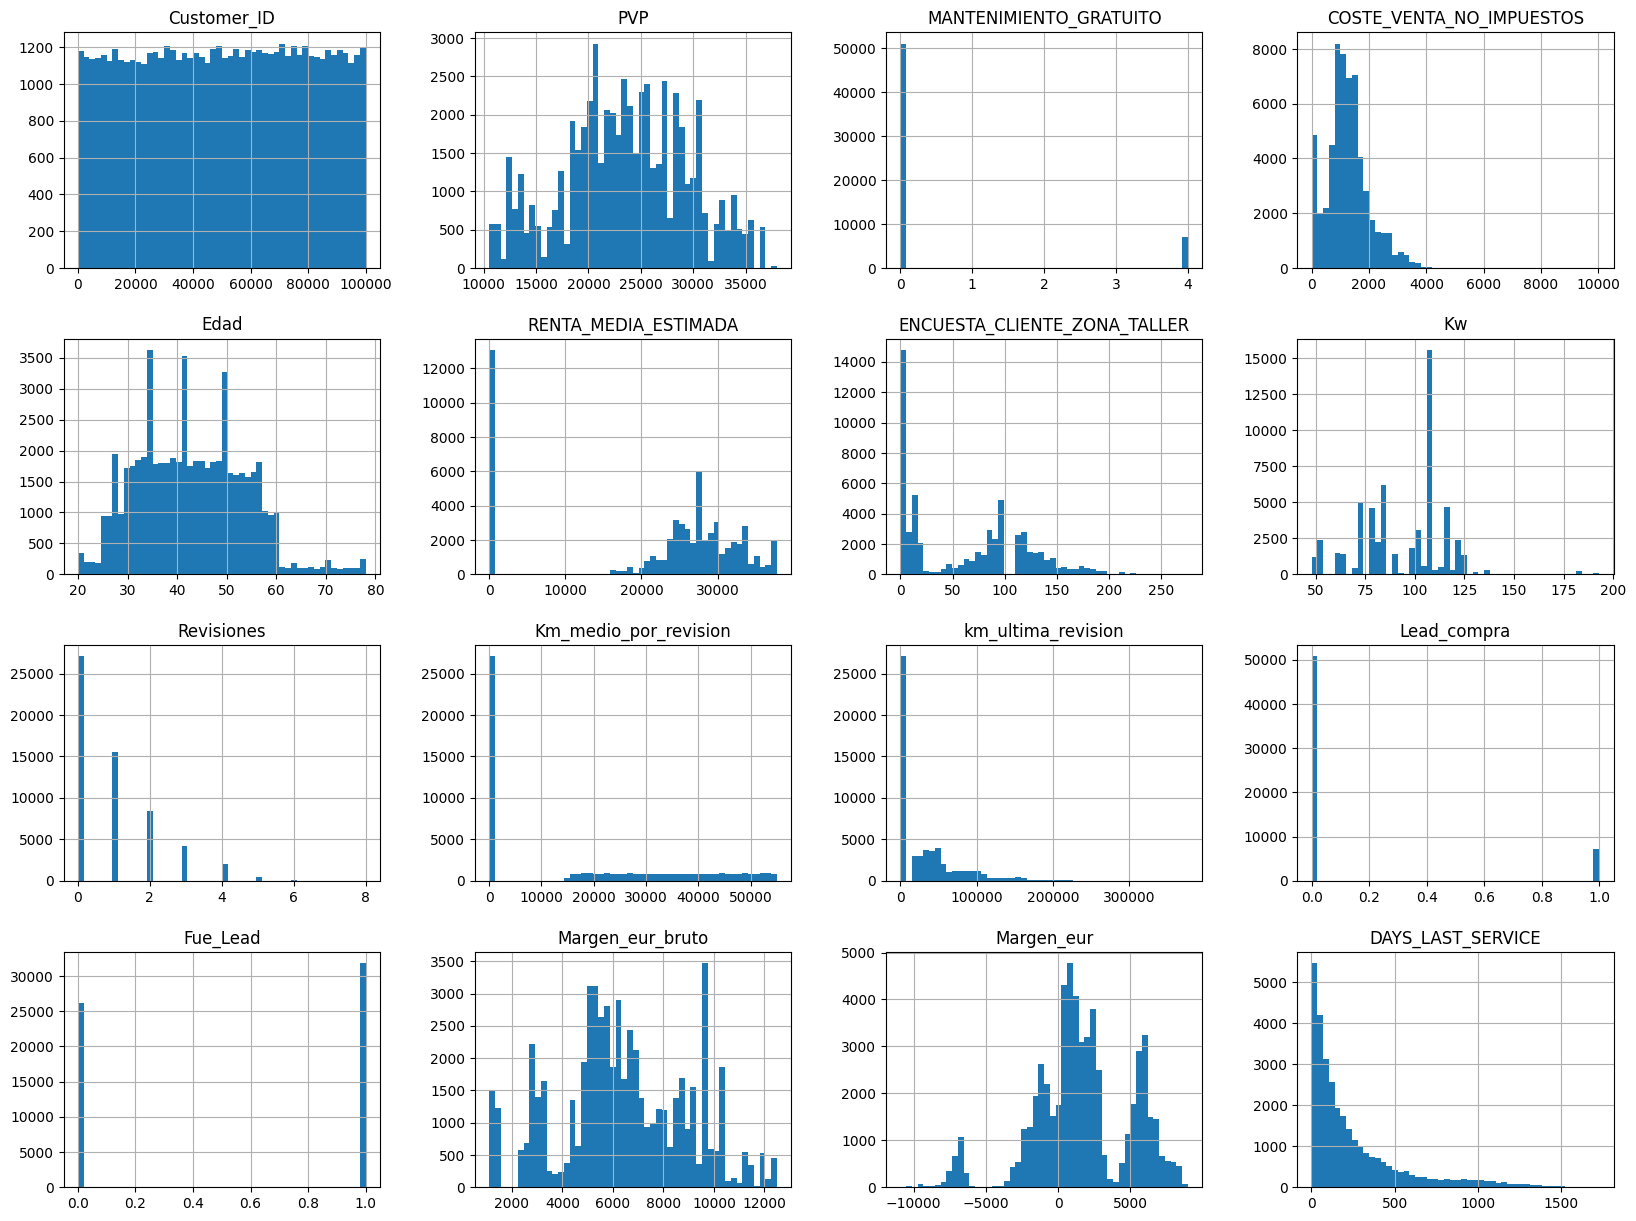

In [8]:
customer_data.hist(bins=50, figsize=(20,15))
plt.show()

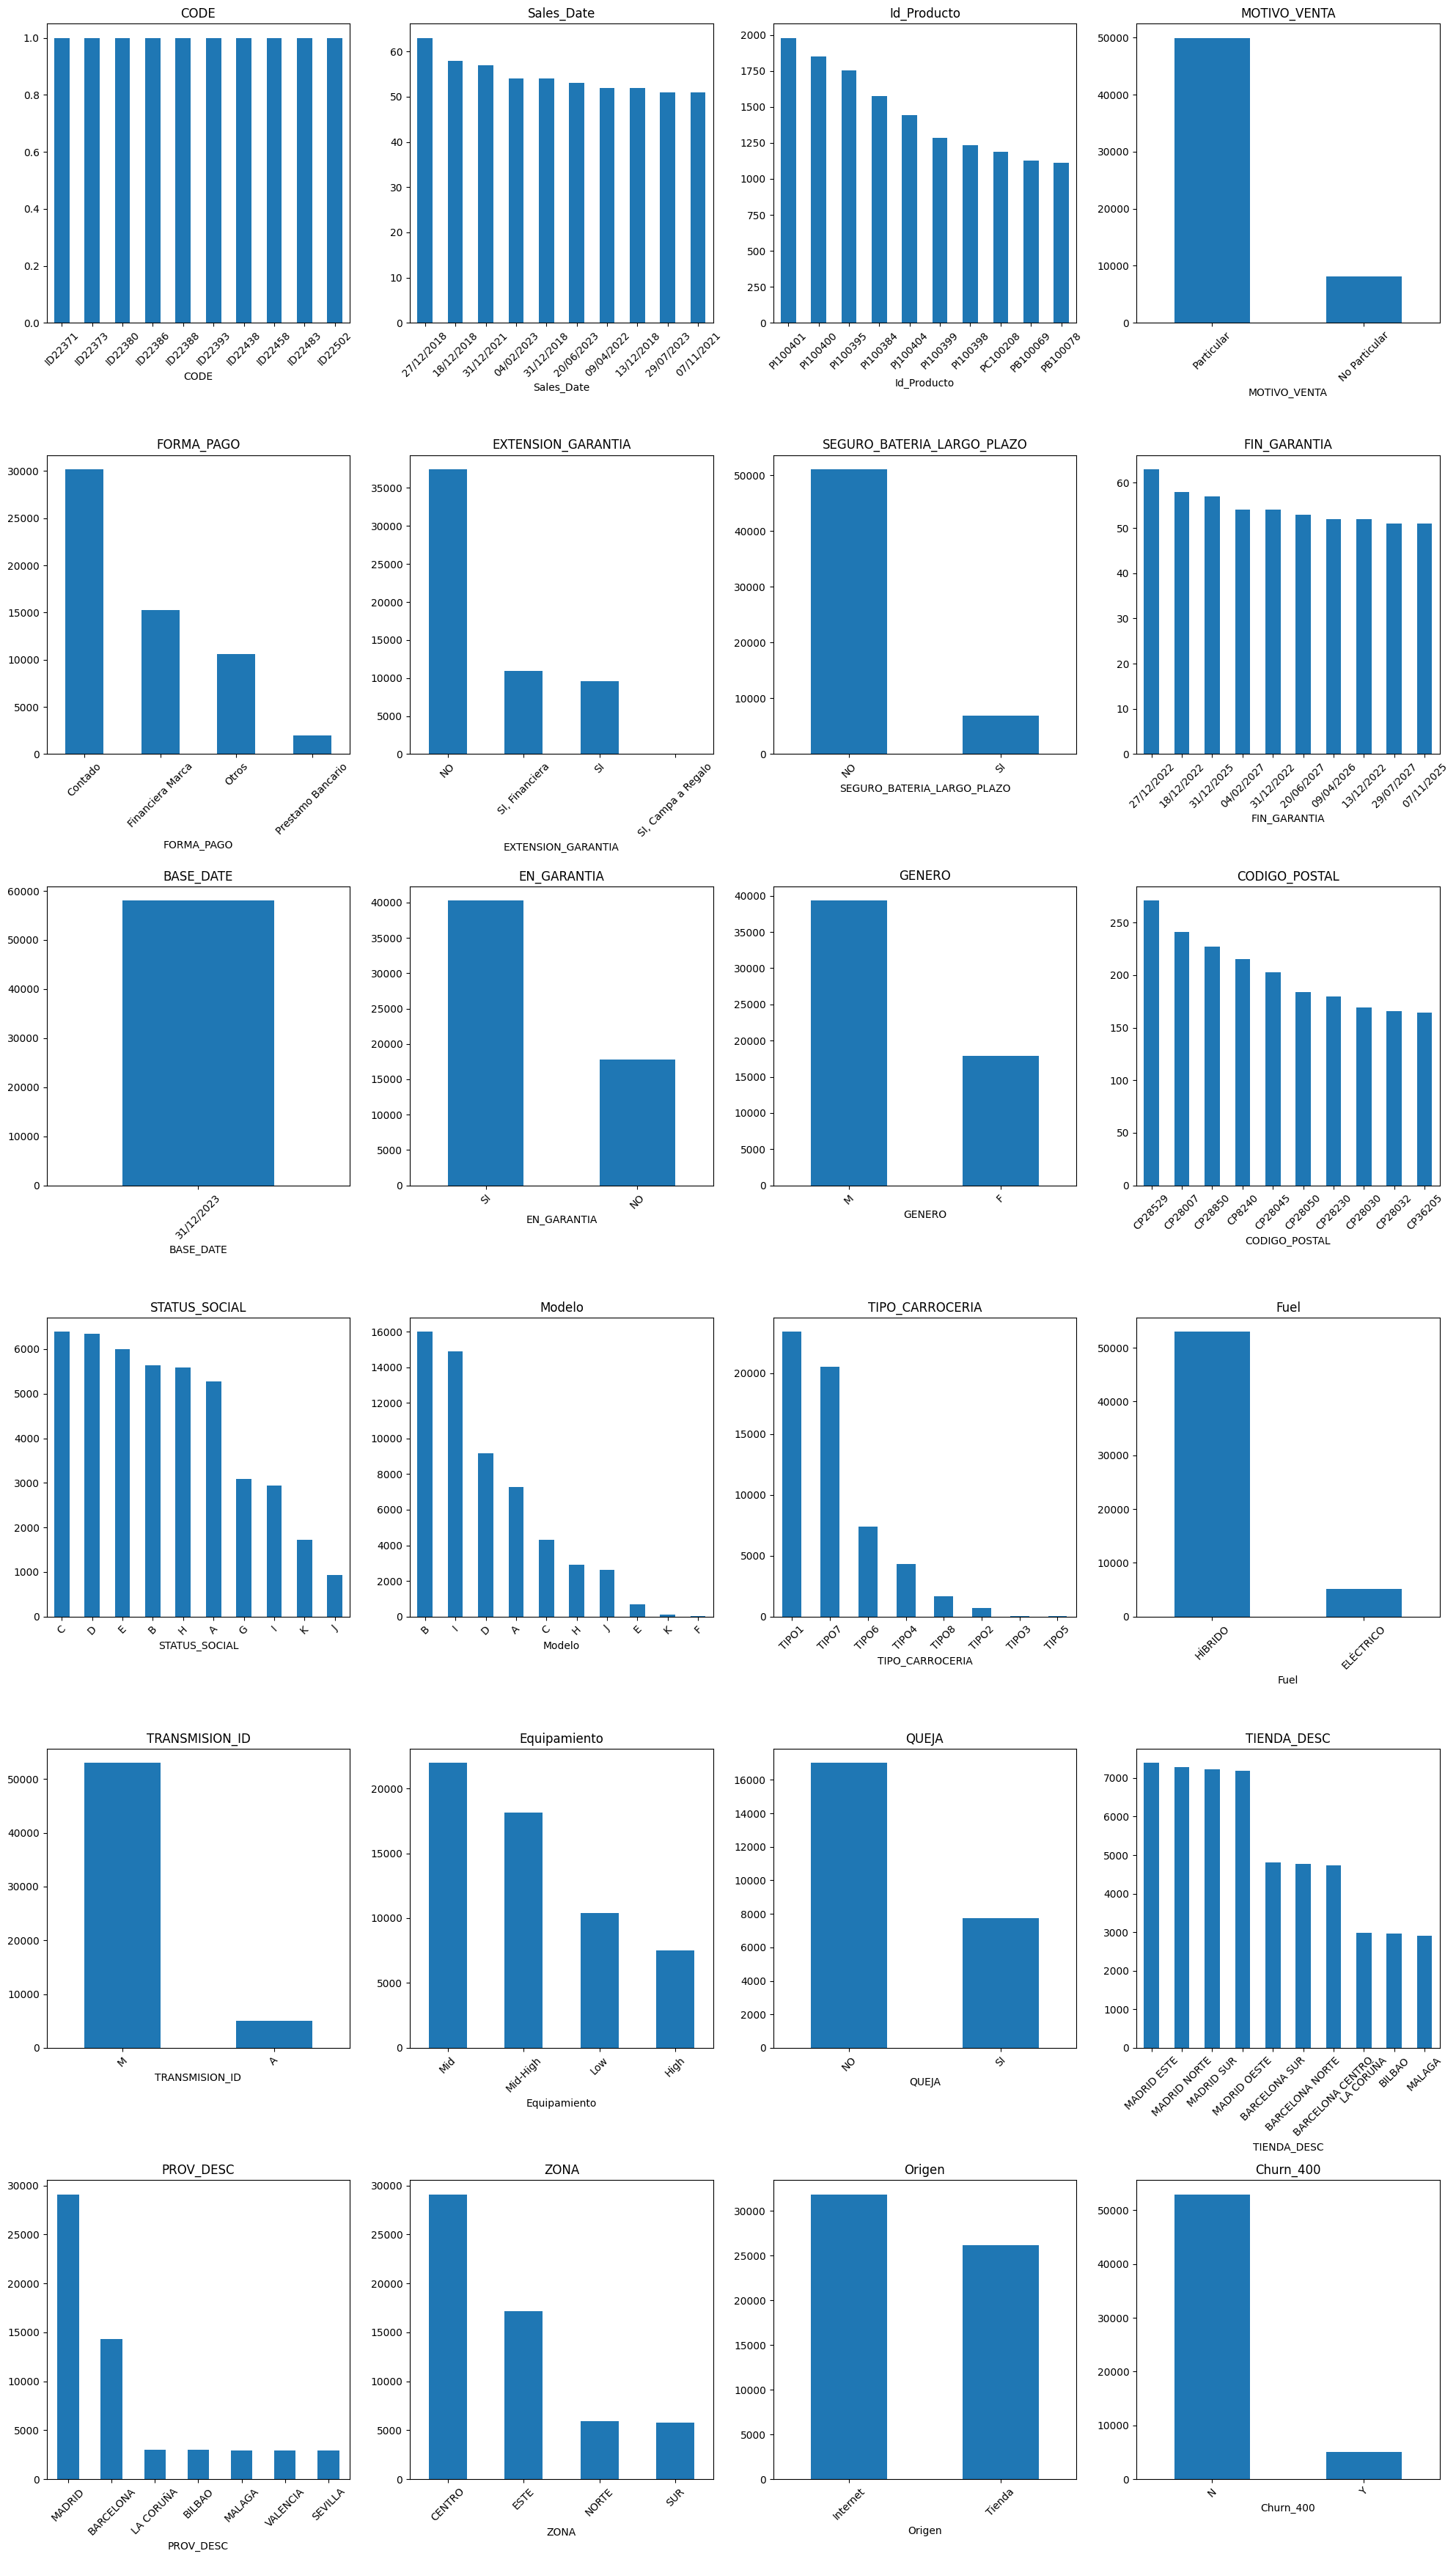

In [9]:
cat_cols = customer_data.select_dtypes(include=['object', 'string']).columns
#cat_cols = [col for col in cat_cols if customer_data[col].nunique() <= 20]

n_cols = 4
n_rows = -(-len(cat_cols) // n_cols)  # redondeo hacia arriba

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 35))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    customer_data[col].value_counts().head(10).plot(kind='bar', ax=axes[i], title=col)
    axes[i].tick_params(axis='x', rotation=45)

# Ocultar los ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [10]:
#customer_data['Id_Producto'].value_counts().plot(kind='bar', figsize=(20, 15), title='Distribución de Id_Producto')

In [11]:
freq_map = customer_data['Id_Producto'].value_counts(normalize=True)
customer_data['Id_Producto_freq'] = customer_data['Id_Producto'].map(freq_map)

In [12]:
customer_data['Churn_400'] = customer_data['Churn_400'].map({'Y': 1, 'N': 0})

customer_data[['Id_Producto_freq', 'Churn_400']].corr()

,Id_Producto_freq,Churn_400
Id_Producto_freq,1.000000,-0.069486
Churn_400,-0.069486,1.000000


array([[<Axes: title={'center': 'Customer_ID'}>,
        <Axes: title={'center': 'PVP'}>,
        <Axes: title={'center': 'MANTENIMIENTO_GRATUITO'}>,
        <Axes: title={'center': 'COSTE_VENTA_NO_IMPUESTOS'}>],
       [<Axes: title={'center': 'Edad'}>,
        <Axes: title={'center': 'RENTA_MEDIA_ESTIMADA'}>,
        <Axes: title={'center': 'ENCUESTA_CLIENTE_ZONA_TALLER'}>,
        <Axes: title={'center': 'Kw'}>],
       [<Axes: title={'center': 'Revisiones'}>,
        <Axes: title={'center': 'Km_medio_por_revision'}>,
        <Axes: title={'center': 'km_ultima_revision'}>,
        <Axes: title={'center': 'Lead_compra'}>],
       [<Axes: title={'center': 'Fue_Lead'}>,
        <Axes: title={'center': 'Margen_eur_bruto'}>,
        <Axes: title={'center': 'Margen_eur'}>,
        <Axes: title={'center': 'DAYS_LAST_SERVICE'}>],
       [<Axes: title={'center': 'Churn_400'}>,
        <Axes: title={'center': 'Id_Producto_freq'}>, <Axes: >, <Axes: >]],
      dtype=object)

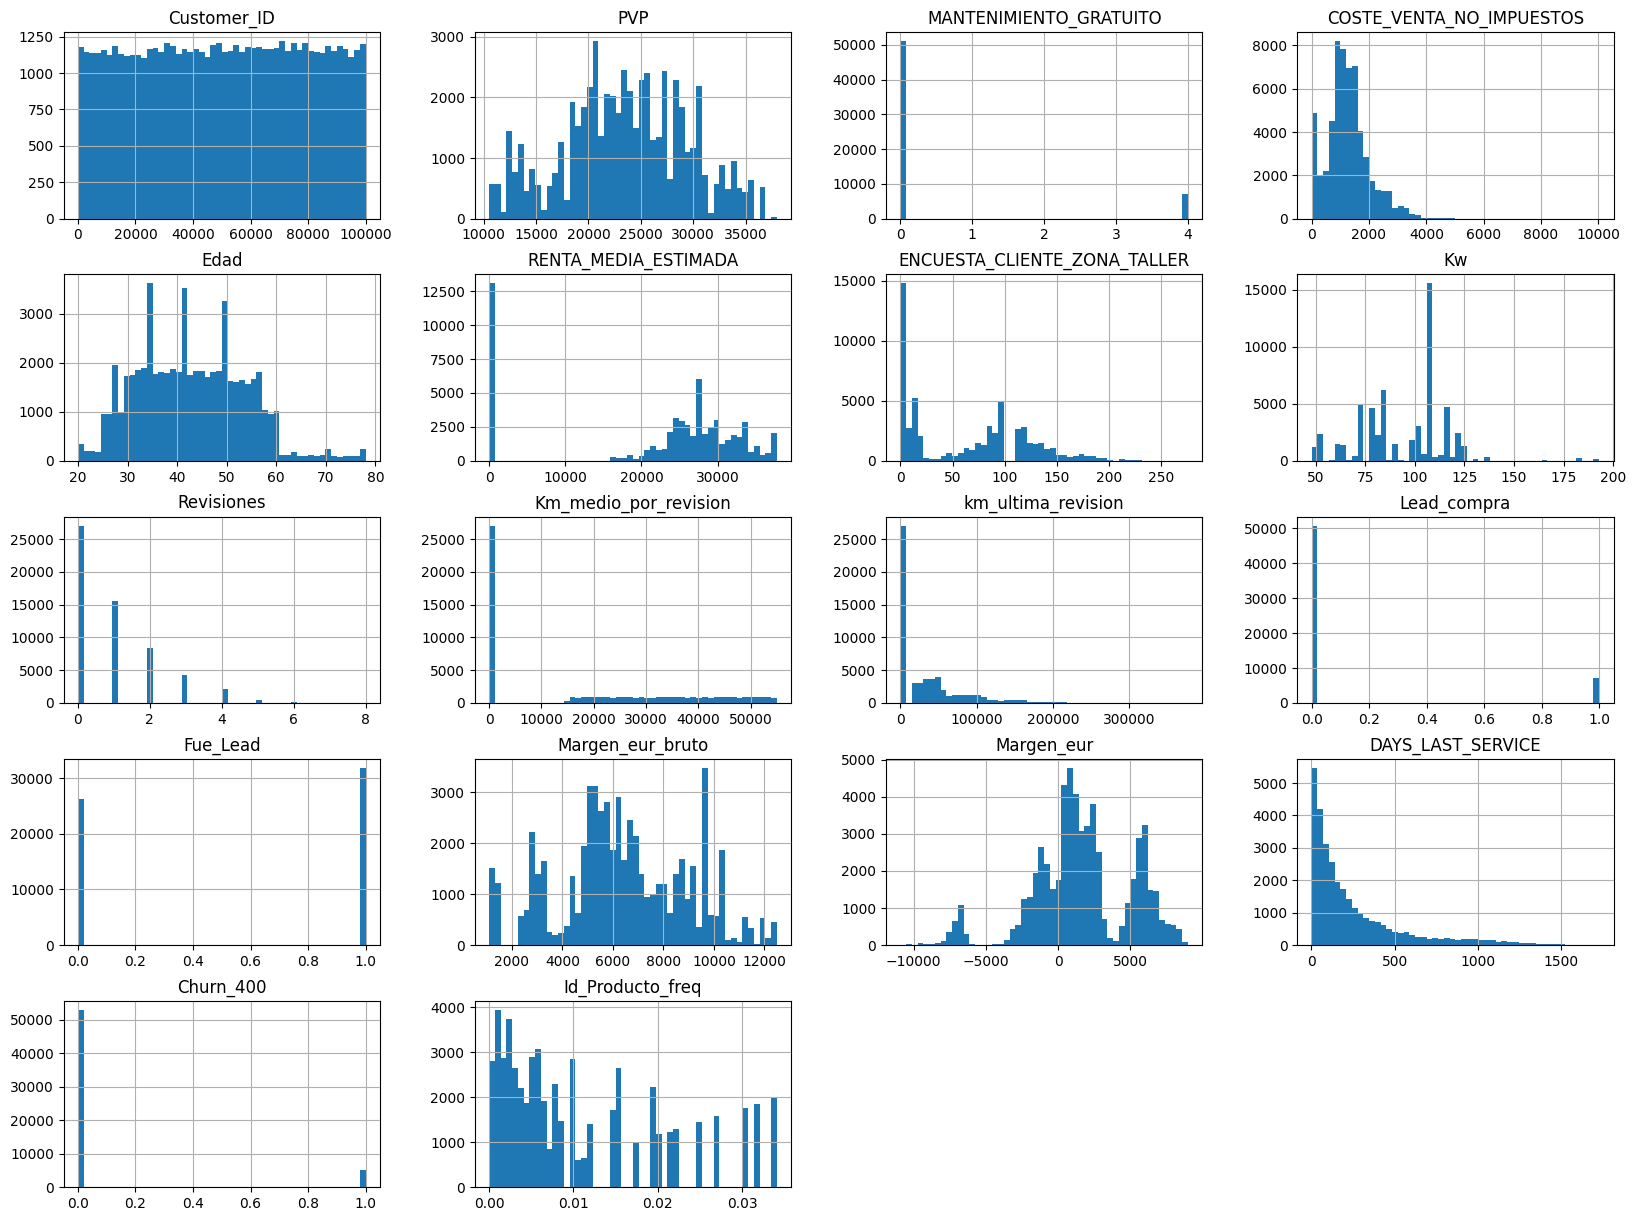

In [13]:
customer_data.hist(bins=50, figsize=(20,15))

array([[<Axes: xlabel='PVP', ylabel='PVP'>,
        <Axes: xlabel='Edad', ylabel='PVP'>,
        <Axes: xlabel='DAYS_LAST_SERVICE', ylabel='PVP'>],
       [<Axes: xlabel='PVP', ylabel='Edad'>,
        <Axes: xlabel='Edad', ylabel='Edad'>,
        <Axes: xlabel='DAYS_LAST_SERVICE', ylabel='Edad'>],
       [<Axes: xlabel='PVP', ylabel='DAYS_LAST_SERVICE'>,
        <Axes: xlabel='Edad', ylabel='DAYS_LAST_SERVICE'>,
        <Axes: xlabel='DAYS_LAST_SERVICE', ylabel='DAYS_LAST_SERVICE'>]],
      dtype=object)

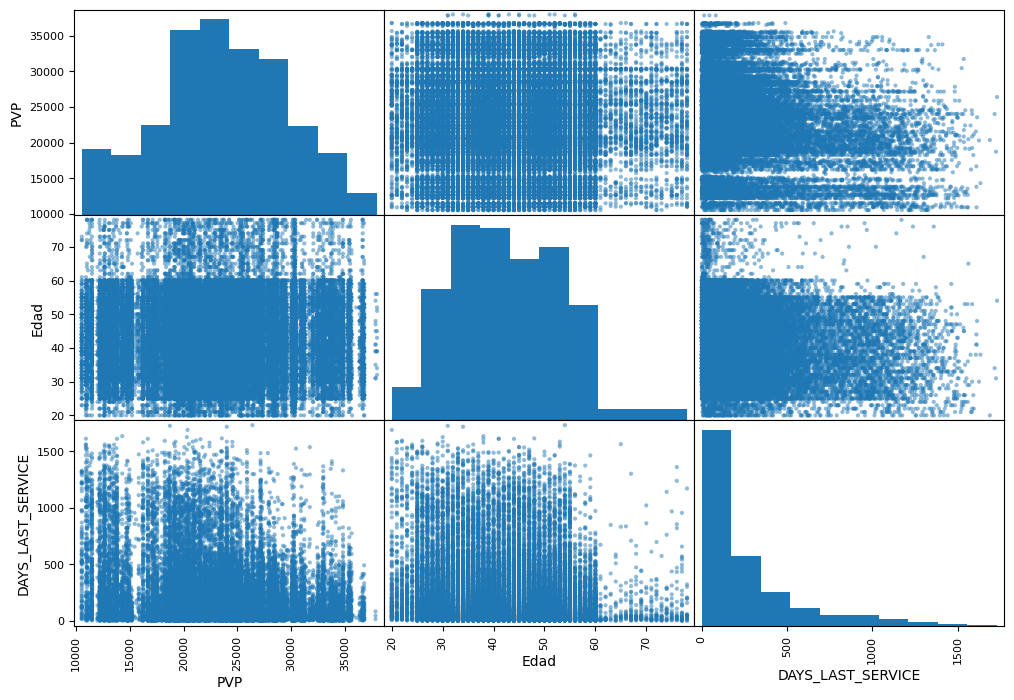

In [14]:
attributes = ['PVP', 'Edad', 'DAYS_LAST_SERVICE']
scatter_matrix(customer_data[attributes], figsize=(12, 8))

In [15]:
print(customer_data['EXTENSION_GARANTIA'].unique())

<StringArray>
['NO', 'SI', 'SI, Financiera', 'SI, Campa a Regalo']
Length: 4, dtype: str
